DNA Disease Prediction

In [ ]:
pip install scikit-allel pandas numpy

In [ ]:
import pandas as pd
import allel
import numpy as np


#### Load and filter GWAS

In [13]:
import pandas as pd
import numpy as np

# Load GWAS data
df = pd.read_csv("GWAS.tsv", sep="\t")

# Check exact column names
print("Columns in file:", df.columns.tolist())

# Keep only necessary columns
df_clean = df[[
    "DISEASE/TRAIT",               # Disease name
    "SNP_ID_CURRENT",               # SNP rsID
    "STRONGEST SNP-RISK ALLELE",   # Risk allele
    "OR or BETA",                   # Effect size
    "CHR_ID",                       # Chromosome
    "CHR_POS"                       # Position (optional)
]].copy()

# Drop rows with missing effect sizes
df_clean = df_clean.dropna(subset=["OR or BETA"])

# Convert OR to beta if necessary
def convert_or_to_beta(x):
    try:
        val = float(x)
        if val > 1:  # Assuming OR format
            return np.log(val)
        else:
            return val
    except:
        return np.nan

df_clean["BETA"] = df_clean["OR or BETA"].apply(convert_or_to_beta)
df_clean = df_clean.dropna(subset=["BETA"])

# Convert P-VALUE to float and filter significant SNPs
if "P-VALUE" in df.columns:
    df_clean["P-VALUE"] = pd.to_numeric(df["P-VALUE"], errors='coerce')
    df_clean = df_clean[df_clean["P-VALUE"] < 5e-8]

# Rename columns
df_clean = df_clean.rename(columns={
    "DISEASE/TRAIT": "DISEASE",
    "SNP_ID_CURRENT": "SNP",
    "STRONGEST SNP-RISK ALLELE": "RISK_ALLELE",
    "CHR_ID": "CHR"
})

# Keep only relevant columns for PRS computation
df_clean = df_clean[["DISEASE", "SNP", "RISK_ALLELE", "BETA", "CHR"]]

# Save final cleaned file
df_clean.to_csv("GWAS_clean_disease.csv", index=False)

print("Cleaned GWAS file saved. Sample:")
df_clean.head()


C:\Users\bhara\AppData\Local\Temp\ipykernel_23744\2154134147.py:5: DtypeWarning: Columns (9,11,12,13,23,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("GWAS.tsv", sep="\t")


Columns in file: ['DATE ADDED TO CATALOG', 'PUBMEDID', 'FIRST AUTHOR', 'DATE', 'JOURNAL', 'LINK', 'STUDY', 'DISEASE/TRAIT', 'INITIAL SAMPLE SIZE', 'REPLICATION SAMPLE SIZE', 'REGION', 'CHR_ID', 'CHR_POS', 'REPORTED GENE(S)', 'MAPPED_GENE', 'UPSTREAM_GENE_ID', 'DOWNSTREAM_GENE_ID', 'SNP_GENE_IDS', 'UPSTREAM_GENE_DISTANCE', 'DOWNSTREAM_GENE_DISTANCE', 'STRONGEST SNP-RISK ALLELE', 'SNPS', 'MERGED', 'SNP_ID_CURRENT', 'CONTEXT', 'INTERGENIC', 'RISK ALLELE FREQUENCY', 'P-VALUE', 'PVALUE_MLOG', 'P-VALUE (TEXT)', 'OR or BETA', '95% CI (TEXT)', 'PLATFORM [SNPS PASSING QC]', 'CNV', 'MAPPED_TRAIT', 'MAPPED_TRAIT_URI', 'STUDY ACCESSION', 'GENOTYPING TECHNOLOGY']
Cleaned GWAS file saved. Sample:


,DISEASE,SNP,RISK_ALLELE,BETA,CHR
175,Plasma proprotein convertase subtilisin/kexin ...,11591147.0,rs11591147-T,0.315,1
176,Plasma proprotein convertase subtilisin/kexin ...,NaN,1:55520994-GCG,0.060,NaN
177,Plasma proprotein convertase subtilisin/kexin ...,45448095.0,rs45448095-T,0.084,1
178,Plasma proprotein convertase subtilisin/kexin ...,2479409.0,rs2479409-A,0.052,1
179,Plasma proprotein convertase subtilisin/kexin ...,6957201.0,rs6957201-C,0.163,7


### Training Model

##### Step - 1 : Preprocess GWAS

In [27]:
df = pd.read_csv("gwas_clean.csv")

# Drop rows with missing SNP or BETA
df = df.dropna(subset=["SNP", "BETA"])

# Make sure BETA is numeric
df["BETA"] = pd.to_numeric(df["BETA"], errors='coerce')
df = df.dropna(subset=["BETA"])
df.head()

C:\Users\bhara\AppData\Local\Temp\ipykernel_23744\112568230.py:1: DtypeWarning: Columns (0,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("gwas_clean.csv")


,SNP,A1,BETA,CHR_ID,CHR_POS
0,11591147.0,rs11591147-T,0.315000,1,55039974.0
2,45448095.0,rs45448095-T,0.084000,1,55039774.0
3,2479409.0,rs2479409-A,0.052000,1,55038977.0
4,6957201.0,rs6957201-C,0.163000,7,5435842.0
5,11591147.0,rs11591147-T,0.374259,1,55039974.0


##### Step - 2 : Simulate genotypes for training

In [28]:

# Create a matrix of genotypes for 100 synthetic individuals
snps = df["SNP"].unique()
n_individuals = 100

# Random genotypes: 0, 1, 2 copies of risk allele
np.random.seed(42)
X = pd.DataFrame(np.random.randint(0, 3, size=(n_individuals, len(snps))), columns=snps)

# Compute "true" PRS using GWAS BETA
beta_dict = df.set_index("SNP")["BETA"].to_dict()
y_true = X.dot(pd.Series(beta_dict))

print("Sample PRS:", y_true.head())



Sample PRS: 0    63095.372379
1    63471.051859
2    63360.993657
3    63285.395782
4    63439.054487
dtype: float64


##### Step - 3 : Train Two Models

In [18]:
pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/8.9 MB 6.1 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/8.9 MB 6.3 MB/s eta 0:00:01
   ---------------- ----------------------- 3.7/8.9 MB 6.1 MB/s eta 0:00:01
   ----------------------- ---------------- 5.2/8.9 MB 6.1 MB/s eta 0:00:01
   ---------------------------- ----------- 6.3/8.9 MB 6.0 MB/s eta 0:00:01
   ---------------------------------- ----- 7.6/8.9 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 6.1 MB/s  0:00:01

   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -----


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


               Model     Dataset        R2       MSE      RMSE       MAE  \
0  Linear Regression  Validation -0.051754  1.034543  1.017125  0.827367   
1  Linear Regression        Test -0.297329  1.118594  1.057636  0.907927   
2      Random Forest  Validation -0.090840  1.072989  1.035852  0.850373   
3      Random Forest        Test -0.443388  1.244529  1.115585  0.976688   

   Accuracy  Precision    Recall        F1  
0      0.65   0.666667  0.923077  0.774194  
1      0.75   0.789474  0.937500  0.857143  
2      0.50   1.000000  0.230769  0.375000  
3      0.40   0.833333  0.312500  0.454545  


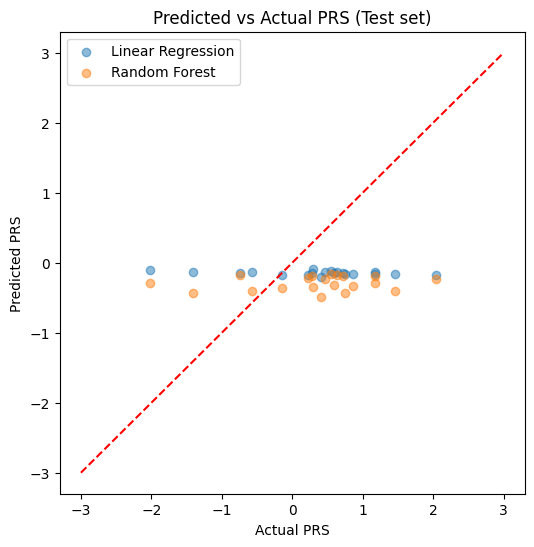

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Prepare synthetic genotype and PRS
df_snps = df.iloc[:100_000].copy()
df_snps = df_snps[['SNP', 'BETA']].dropna()
df_snps = df_snps.drop_duplicates(subset='SNP')
snps = df_snps['SNP'].values
betas = df_snps['BETA'].values
n_individuals = 100
np.random.seed(42)
X = pd.DataFrame(np.random.randint(0,3,size=(n_individuals, len(snps))), columns=snps)
y_true = X.dot(pd.Series(betas, index=snps))
y_true = (y_true - y_true.mean()) / y_true.std()
X['PRS'] = y_true

train_val, test = train_test_split(X, test_size=0.2, random_state=42)
train, val = train_test_split(train_val, test_size=0.25, random_state=42)

X_train = train[snps].astype(float)
y_train = train['PRS'].astype(float)
X_val = val[snps].astype(float)
y_val = val['PRS'].astype(float)
X_test = test[snps].astype(float)
y_test = test['PRS'].astype(float)

# Train models
lr = LinearRegression()
lr.fit(X_train, y_train)
y_val_pred_lr = lr.predict(X_val)
y_test_pred_lr = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_val_pred_rf = rf.predict(X_val)
y_test_pred_rf = rf.predict(X_test)

# Convert PRS to binary: high-risk vs low-risk
threshold = np.median(y_train)
y_val_bin = (y_val > threshold).astype(int)
y_val_pred_lr_bin = (y_val_pred_lr > threshold).astype(int)
y_val_pred_rf_bin = (y_val_pred_rf > threshold).astype(int)

y_test_bin = (y_test > threshold).astype(int)
y_test_pred_lr_bin = (y_test_pred_lr > threshold).astype(int)
y_test_pred_rf_bin = (y_test_pred_rf > threshold).astype(int)

# Function to calculate metrics
def calc_metrics(y_true_reg, y_pred_reg, y_true_bin, y_pred_bin):
    r2 = r2_score(y_true_reg, y_pred_reg)
    mse = mean_squared_error(y_true_reg, y_pred_reg)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_reg, y_pred_reg)
    acc = accuracy_score(y_true_bin, y_pred_bin)
    prec = precision_score(y_true_bin, y_pred_bin)
    rec = recall_score(y_true_bin, y_pred_bin)
    f1 = f1_score(y_true_bin, y_pred_bin)
    return r2, mse, rmse, mae, acc, prec, rec, f1

# Collect metrics
metrics = []
for model_name, y_val_pred, y_test_pred, y_val_pred_bin, y_test_pred_bin in [
    ('Linear Regression', y_val_pred_lr, y_test_pred_lr, y_val_pred_lr_bin, y_test_pred_lr_bin),
    ('Random Forest', y_val_pred_rf, y_test_pred_rf, y_val_pred_rf_bin, y_test_pred_rf_bin)
]:
    r2_val, mse_val, rmse_val, mae_val, acc_val, prec_val, rec_val, f1_val = calc_metrics(y_val, y_val_pred, y_val_bin, y_val_pred_bin)
    r2_test, mse_test, rmse_test, mae_test, acc_test, prec_test, rec_test, f1_test = calc_metrics(y_test, y_test_pred, y_test_bin, y_test_pred_bin)
    metrics.append([model_name, 'Validation', r2_val, mse_val, rmse_val, mae_val, acc_val, prec_val, rec_val, f1_val])
    metrics.append([model_name, 'Test', r2_test, mse_test, rmse_test, mae_test, acc_test, prec_test, rec_test, f1_test])

metrics_df = pd.DataFrame(metrics, columns=['Model','Dataset','R2','MSE','RMSE','MAE','Accuracy','Precision','Recall','F1'])
print(metrics_df)

# Plot predicted vs actual PRS for test set
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_lr, alpha=0.5, label='Linear Regression')
plt.scatter(y_test, y_test_pred_rf, alpha=0.5, label='Random Forest')
plt.plot([-3,3], [-3,3], 'r--')
plt.xlabel("Actual PRS")
plt.ylabel("Predicted PRS")
plt.title("Predicted vs Actual PRS (Test set)")
plt.legend()
plt.show()


✅ Saved: patient_genotype_disease_data.csv
